In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
data = pd.read_csv('Datasets/titanic_train.csv')

In [63]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [65]:
data['Embarked'].unique()

<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [66]:
data.shape

(891, 8)

# Perform EDA

In [67]:
data.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [68]:
mn = data['Age'].mean()

In [69]:
data['Age'] = data['Age'].fillna(mn)

In [70]:
data.dropna(inplace=True)

# Check Ourliers

In [71]:
def checkOutliers(data, column):
    plt.figure(figsize=(30, 5))
    plt.subplot(1, 2, 1)
    plt.boxplot(data[column])
    plt.subplot(1, 2, 2)
    sns.histplot(data=data, x=data[column], kde=True)
    plt.axvline(data[column].mean()+3*data[column].std())
    plt.axvline(data[column].mean()-3*data[column].std())

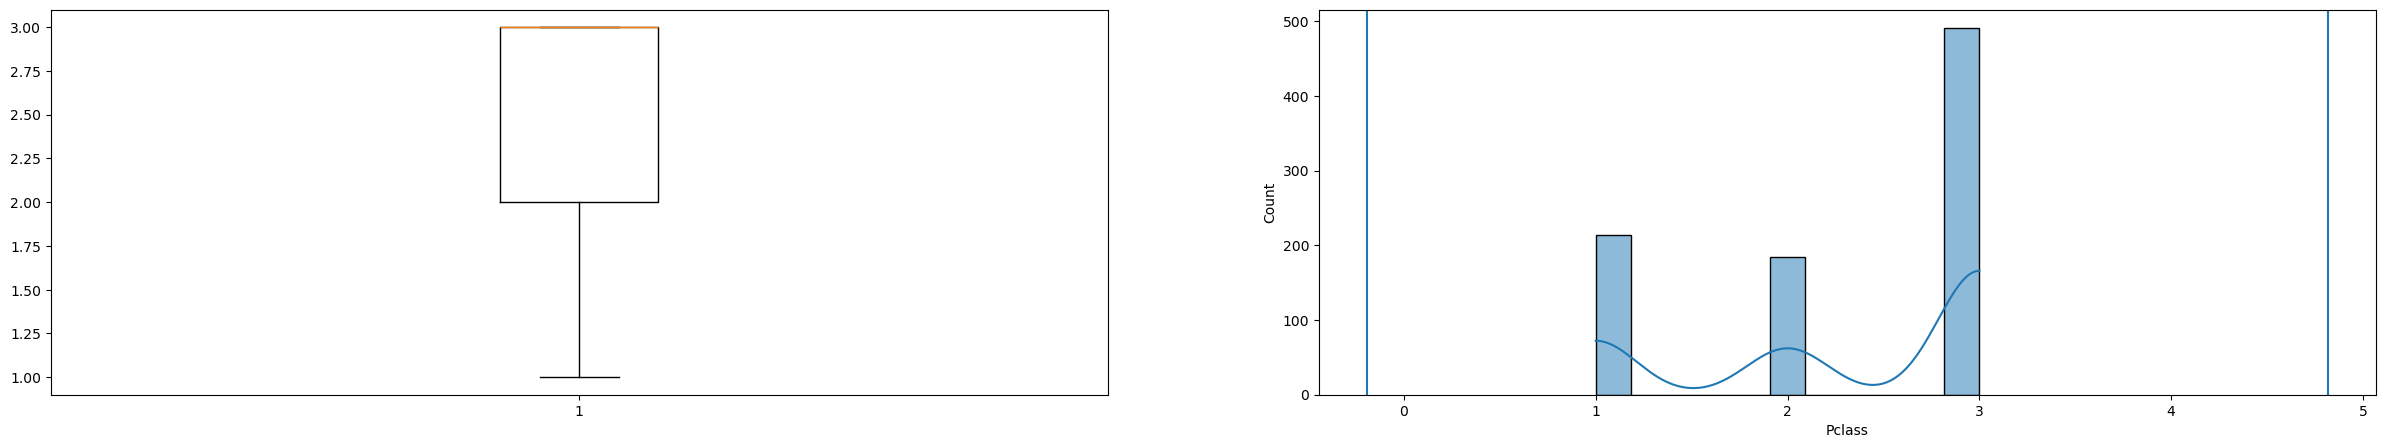

In [72]:
checkOutliers(data, 'Pclass')

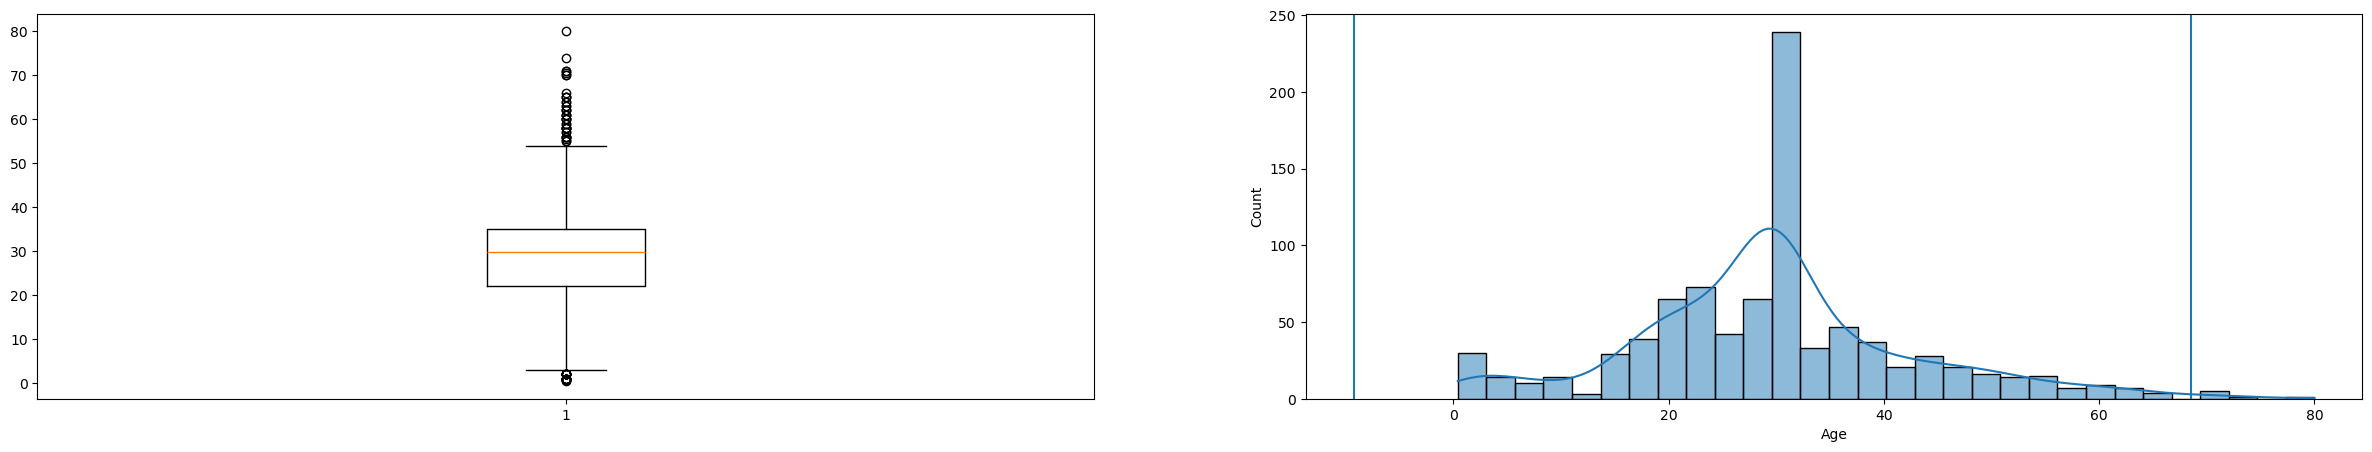

In [73]:
checkOutliers(data, 'Age')

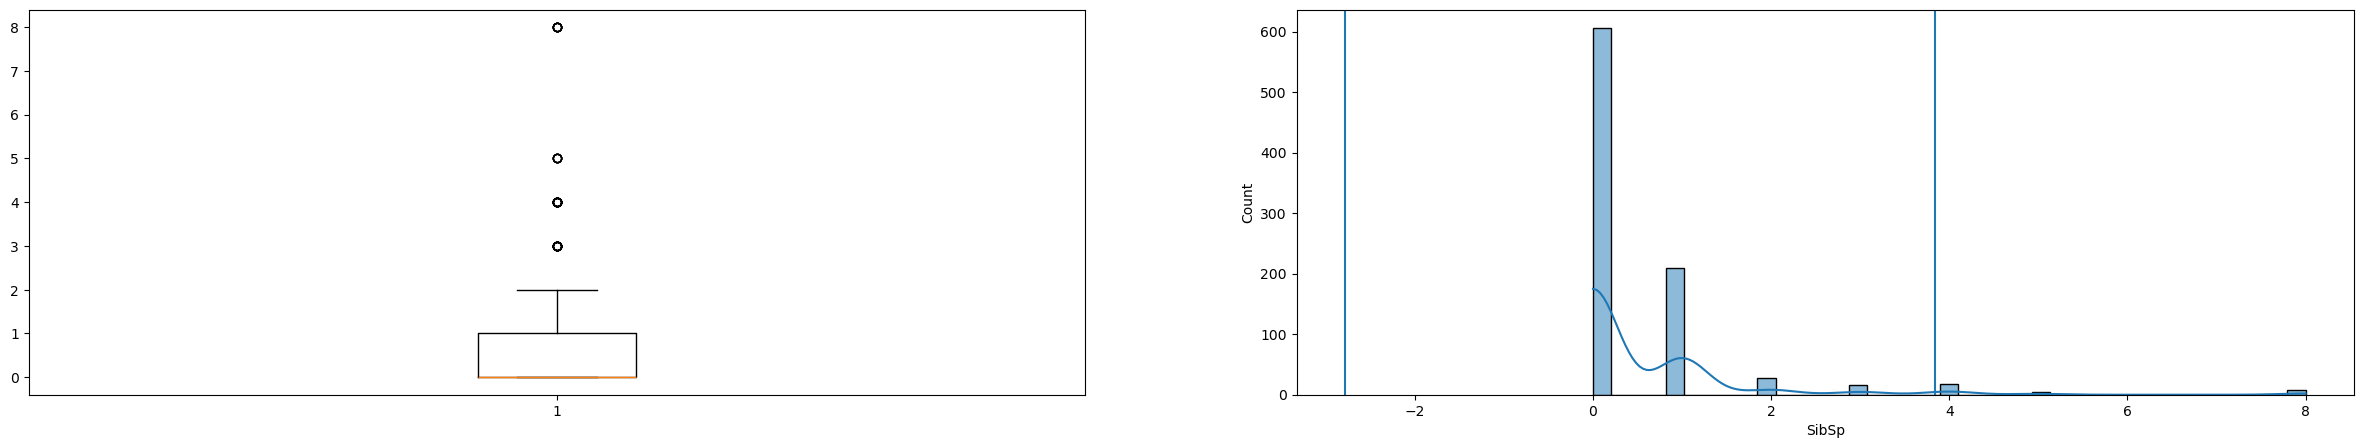

In [74]:
checkOutliers(data, 'SibSp')

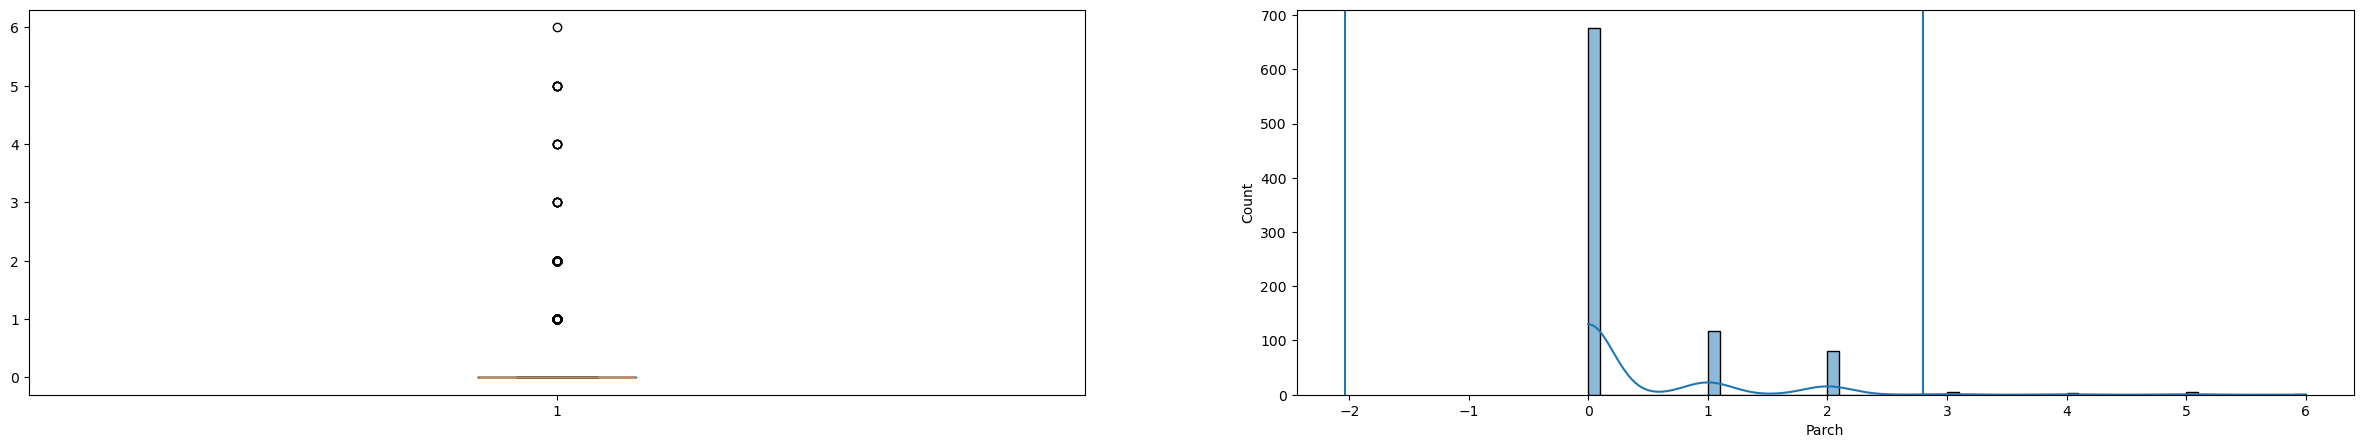

In [75]:
checkOutliers(data, 'Parch')

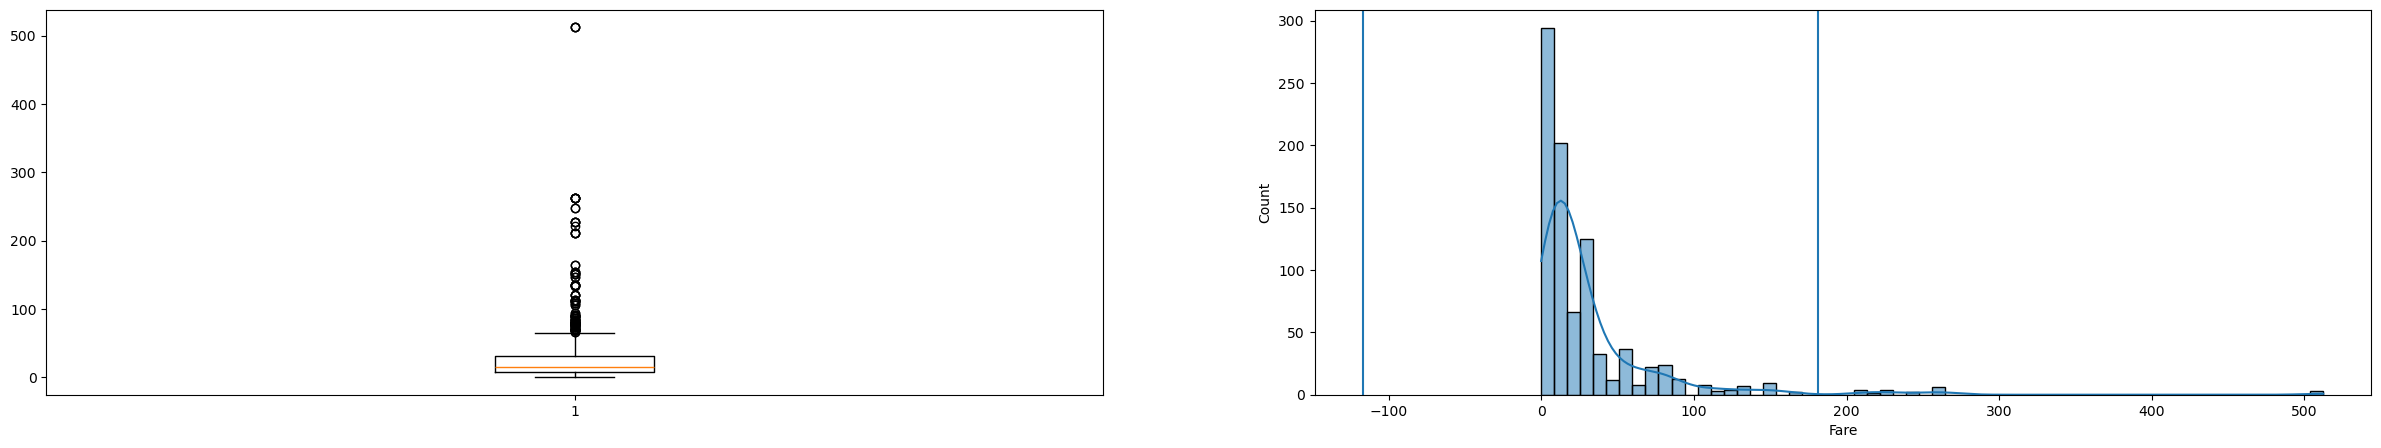

In [76]:
checkOutliers(data, 'Fare')

# Handle Outliers

In [77]:
def handleOutliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    
    upper_b = q3 + 1.5*iqr
    lower_b = q1 - 1.5*iqr
    data.loc[data[column]>upper_b, column]=upper_b
    data.loc[data[column]<lower_b, column]=lower_b

In [78]:
handleOutliers(data, 'Age')

In [79]:
# handleOutliers(data, 'SibSp')

In [80]:
handleOutliers(data, 'Parch')

In [81]:
handleOutliers(data, 'Fare')

# Data Encoding

In [82]:
data['Sex'].unique()

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

In [83]:
data['Sex'] = data['Sex'].replace({'male':1, 'female':0})

In [84]:
data['Embarked'].unique()

<ArrowStringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [85]:
data['Embarked'] = data['Embarked'].replace({'S':0, 'C':1, 'Q':2})

<Axes: >

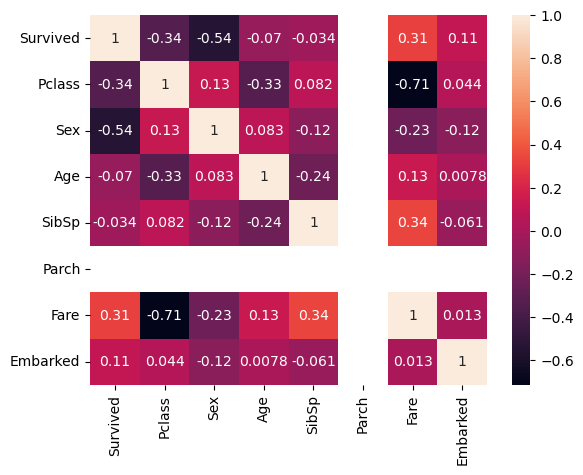

In [86]:
sns.heatmap(data.corr(), annot=True)

In [87]:
x = data.drop(['Survived', 'Parch'], axis=1)
y = data['Survived']

In [88]:
data['Survived'].value_counts()

Survived
0    549
1    340
Name: count, dtype: int64

In [89]:
from imblearn.over_sampling import SMOTE

In [90]:
sm = SMOTE()

In [91]:
x_sm, y_sm = sm.fit_resample(x, y)

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
x_train, x_test, y_train, y_test = train_test_split(x_sm, y_sm, test_size=0.3, random_state=42)

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

In [95]:
rf = RandomForestClassifier(max_depth=8, min_samples_leaf=3, min_samples_split=5)
parameter = {'n_estimators':[200]}
gsv = GridSearchCV(estimator=rf, param_grid=parameter, scoring='accuracy')

In [96]:
result = cross_validate(rf, x_train, y_train)

In [97]:
gsv.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...mples_split=5)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'n_estimators': [200]}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate pa

In [98]:
test_pred = gsv.predict(x_test)

In [99]:
train_pred = gsv.predict(x_train)

In [100]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [101]:
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

In [102]:
print('Training Accuracy : ', train_acc)
print('Testing Accuracy : ', test_acc)

Training Accuracy :  0.90625
Testing Accuracy :  0.8424242424242424


In [103]:
confusion_matrix(y_test, test_pred)

array([[143,  25],
       [ 27, 135]])

In [104]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.84      0.85      0.85       168
           1       0.84      0.83      0.84       162

    accuracy                           0.84       330
   macro avg       0.84      0.84      0.84       330
weighted avg       0.84      0.84      0.84       330



In [105]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0
1,1,1,0,38.0,1,0,65.6563,1
2,1,3,0,26.0,0,0,7.9250,0
3,1,1,0,35.0,1,0,53.1000,0
4,0,3,1,35.0,0,0,8.0500,0


In [112]:
pclass = int(input('Enter Pclass : '))
gender = input('Enter Gender : ')
if gender == 'Female':
    gender = int(0)
elif gender == 'Male':
    gender = int(1)
age = int(input('Enter Age : '))
sibsp = int(input('Enter Sibsp : '))
fare = float(input('Enter Fare : '))
embarked = int(input('Enter Embarked : '))
new_value = pd.DataFrame([[pclass, gender, age, sibsp, fare, embarked]], 
                        columns=['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked'])
result = gsv.predict(new_value)
print(result)

Enter Pclass :  3
Enter Gender :  Female
Enter Age :  26
Enter Sibsp :  0
Enter Fare :  7.9
Enter Embarked :  0


[0]


In [107]:
import pickle
with open("random_model.pkl", "wb") as f:
    pickle.dump(gsv, f)

In [108]:
data['Pclass'].unique()

array([3, 1, 2])

In [109]:
# import os
# print("Saved at:", os.getcwd())
